# Task 2 — Topic Distribution Analysis on `part_0.parquet` with BERTopic (V02)

This notebook profiles the content distribution of one shard (`part_0.parquet`) for Task 2 using:

- **BERT-family sentence embeddings**
- **BERTopic** for topic modeling
- improved **topic representation**
- topic words / topic labels / topic distribution outputs
- GPU-first embedding, optional cuDF for parquet loading

## Why this version
The previous BERTopic version could produce poor topic labels such as stopword-heavy strings like `the_to_and_of`, and it could also fail when `get_topic_info()` was called before a successful fit.

This version fixes that by:

1. using a better **vectorizer_model**
2. using **KeyBERTInspired** for topic representation
3. explicitly checking that BERTopic fit succeeded
4. only calling `get_topic_info()` after the model is confirmed fitted

## Main outputs
- topic summary table
- topic words table
- representative documents
- topic bar chart
- topic pie chart

In [1]:
# =========================================================
# 0. Config
# =========================================================
from pathlib import Path

PARQUET_PATH = Path("../data/AUTokens50/part_0.parquet").resolve()
OUTPUT_DIR = Path("../cleaning_outputs/week4/").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TEXT_COL = "text"
URL_COL = "url"

# Sampling
SAMPLE_SIZE = 10000
RANDOM_SEED = 42
MAX_TEXT_LEN = 1500

# Embedding model
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# BERTopic controls
MIN_TOPIC_SIZE = 50
NR_TOP_WORDS = 10
TOP_DOCS_PER_TOPIC = 10

if not PARQUET_PATH.exists():
    raise FileNotFoundError(f"Could not find parquet file at: {PARQUET_PATH}")

print("PARQUET_PATH =", PARQUET_PATH)
print("OUTPUT_DIR   =", OUTPUT_DIR)
print("EMBED_MODEL  =", EMBED_MODEL_NAME)

PARQUET_PATH = /home/jovyan/data/AUTokens50/part_0.parquet
OUTPUT_DIR   = /home/jovyan/cleaning_outputs/week4
EMBED_MODEL  = sentence-transformers/all-MiniLM-L6-v2


## Cell purpose: install dependencies

This notebook uses:
- `sentence-transformers` for BERT-family embeddings
- `BERTopic` for topic modeling
- `CountVectorizer` + `KeyBERTInspired` for better topic words
- `matplotlib` for static charts
- optional `cudf` for faster parquet loading

In [2]:
# =========================================================
# 1. Install / check dependencies
# =========================================================
import sys, subprocess, importlib.util

def has_package(pkg_name):
    return importlib.util.find_spec(pkg_name) is not None

def ensure_package(pkg_name, pip_name=None):
    pip_name = pip_name or pkg_name
    if not has_package(pkg_name):
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"{pkg_name} already installed.")

ensure_package("numpy", "numpy")
ensure_package("pandas", "pandas")
ensure_package("pyarrow", "pyarrow")
ensure_package("sklearn", "scikit-learn")
ensure_package("matplotlib", "matplotlib")
ensure_package("sentence_transformers", "sentence-transformers")
ensure_package("bertopic", "bertopic")
ensure_package("umap", "umap-learn")
ensure_package("hdbscan", "hdbscan")

if has_package("cudf"):
    print("cudf is available.")
else:
    print("cudf not found. Will fall back to pandas/pyarrow.")

numpy already installed.
pandas already installed.
pyarrow already installed.
sklearn already installed.
matplotlib already installed.
sentence_transformers already installed.
bertopic already installed.
umap already installed.
hdbscan already installed.
cudf not found. Will fall back to pandas/pyarrow.


## Cell purpose: imports and device check

In [3]:
# =========================================================
# 2. Imports and device check
# =========================================================
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_CUDF = has_package("cudf")

print("Torch version:", torch.__version__)
print("Torch device :", DEVICE)
if DEVICE == "cuda":
    print("GPU name     :", torch.cuda.get_device_name(0))
print("Use cuDF     :", USE_CUDF)

Torch version: 2.5.1+cu121
Torch device : cuda
GPU name     : NVIDIA L4
Use cuDF     : False


## Optional: Hugging Face token

In [4]:
# =========================================================
# 3. Optional HF token
# =========================================================
HF_TOKEN = os.environ.get("HF_TOKEN", None)

# If needed:
# HF_TOKEN = "your_hf_token_here"
# os.environ["HF_TOKEN"] = HF_TOKEN

print("HF_TOKEN set:", HF_TOKEN is not None)

HF_TOKEN set: False


## Cell purpose: load parquet and sample texts

In [5]:
# =========================================================
# 4. Load parquet and sample
# =========================================================
def load_parquet_auto(path, columns):
    if USE_CUDF:
        try:
            import cudf
            print("Using cudf for parquet loading.")
            gdf = cudf.read_parquet(path, columns=columns)
            return gdf.to_pandas()
        except Exception as e:
            print("cuDF load failed, falling back to pandas:", repr(e))
    return pd.read_parquet(path, columns=columns)

df = load_parquet_auto(PARQUET_PATH, columns=[TEXT_COL, URL_COL])
print("Loaded shape:", df.shape)

work_df = df.dropna(subset=[TEXT_COL]).copy()
work_df[TEXT_COL] = work_df[TEXT_COL].astype(str).str.slice(0, MAX_TEXT_LEN)
work_df[URL_COL] = work_df[URL_COL].astype(str)

if len(work_df) > SAMPLE_SIZE:
    work_df = work_df.sample(SAMPLE_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)
else:
    work_df = work_df.reset_index(drop=True)

print("Working shape:", work_df.shape)
display(work_df.head(3))

Loaded shape: (278106, 2)
Working shape: (10000, 2)


,text,url
0,"A couple of decades ago, when my head was rout...",http://www.northerndailyleader.com.au/story/12...
1,"Transcript of Doorstop Interview, Hobart\nTHU ...",http://www.pm.gov.au/press-office/transcript-d...
2,Name: Kevin Mitnick\nOccupation: Security Cons...,"http://www.pcauthority.com.au/Feature/22570,at..."


## Cell purpose: sanity checks

In [6]:
# =========================================================
# 5. Sanity checks
# =========================================================
work_df["char_len"] = work_df[TEXT_COL].str.len()
print(work_df["char_len"].describe())
display(work_df[[URL_COL, TEXT_COL, "char_len"]].head(5))

count    10000.0
mean      1500.0
std          0.0
min       1500.0
25%       1500.0
50%       1500.0
75%       1500.0
max       1500.0
Name: char_len, dtype: float64


,url,text,char_len
0,http://www.northerndailyleader.com.au/story/12...,"A couple of decades ago, when my head was rout...",1500
1,http://www.pm.gov.au/press-office/transcript-d...,"Transcript of Doorstop Interview, Hobart\nTHU ...",1500
2,"http://www.pcauthority.com.au/Feature/22570,at...",Name: Kevin Mitnick\nOccupation: Security Cons...,1500
3,http://insideadog.com.au/books/city-fallen-angels,After eighteen years as a political prisoner i...,1500
4,http://www.uow.edu.au/~/bmartin/dissent/docume...,MEDICINE WEB SITE Background Every attempt is\...,1500


## Cell purpose: compute BERT-family embeddings

In [7]:
# =========================================================
# 6. Compute embeddings
# =========================================================
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)

docs = work_df[TEXT_COL].tolist()
embeddings = embed_model.encode(
    docs,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embedding shape:", embeddings.shape)
print("NaN count:", np.isnan(embeddings).sum())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Embedding shape: (10000, 384)
NaN count: 0


## Cell purpose: fit BERTopic with better topic representation

This version uses:

- `CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=5)`
- `KeyBERTInspired()`

These changes usually reduce stopword-heavy topic names and make topic words more interpretable.

In [8]:
# =========================================================
# 7. Fit BERTopic
# =========================================================
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)

representation_model = KeyBERTInspired()

topic_model = BERTopic(
    embedding_model=embed_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    min_topic_size=MIN_TOPIC_SIZE,
    nr_topics="auto",
    top_n_words=NR_TOP_WORDS,
    calculate_probabilities=False,
    verbose=True,
    low_memory=True,
)

fit_ok = False
try:
    topics, probs = topic_model.fit_transform(docs, embeddings)
    fit_ok = True
    print("BERTopic fit completed.")
except Exception as e:
    print("BERTopic fit failed:")
    print(repr(e))
    fit_ok = False

if not fit_ok or getattr(topic_model, "topics_", None) is None:
    raise RuntimeError(
        "BERTopic did not fit successfully. "
        "Check the error above before running downstream cells."
    )

# Optional refinement of topic representations after fitting
topic_model.update_topics(
    docs,
    vectorizer_model=vectorizer_model
)

work_df["topic_id"] = topics
print(work_df["topic_id"].value_counts().head(20))

2026-04-20 07:06:13,782 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-20 07:06:47,629 - BERTopic - Dimensionality - Completed ✓
2026-04-20 07:06:47,632 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-20 07:06:48,163 - BERTopic - Cluster - Completed ✓
2026-04-20 07:06:48,165 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-20 07:06:51,617 - BERTopic - Representation - Completed ✓
2026-04-20 07:06:51,619 - BERTopic - Topic reduction - Reducing number of topics
2026-04-20 07:06:51,631 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-20 07:06:56,587 - BERTopic - Representation - Completed ✓
2026-04-20 07:06:56,592 - BERTopic - Topic reduction - Reduced number of topics from 33 to 22


BERTopic fit completed.
topic_id
-1     3765
 0     1337
 1      940
 2      863
 3      353
 4      304
 5      295
 6      232
 7      225
 8      211
 9      208
 10     203
 11     178
 12     142
 13     119
 14     115
 15     114
 16     110
 17      92
 18      78
Name: count, dtype: int64


## Cell purpose: topic summary table

This cell only runs after BERTopic fit has succeeded.

In [9]:
# =========================================================
# 8. Topic summary table
# =========================================================
if getattr(topic_model, "topics_", None) is None:
    raise RuntimeError("topic_model is not fitted. Run Cell 7 successfully first.")

topic_info = topic_model.get_topic_info()
topic_info["clean_name"] = topic_info["Name"].str.replace("_", " ", regex=False)

display(topic_info[["Topic", "Count", "Name", "clean_name"]].head(20))

topic_info_out = OUTPUT_DIR / "part_0_bertopic_topic_info_v02.csv"
topic_info.to_csv(topic_info_out, index=False)
print("Saved:", topic_info_out)

,Topic,Count,Name,clean_name
0,-1,3765,-1_people_time_australia_new,-1 people time australia new
1,0,1337,0_film_music_like_movie,0 film music like movie
2,1,940,1_labor_government_party_minister,1 labor government party minister
3,2,863,2_season_club_game_team,2 season club game team
4,3,353,3_baby_just_time_know,3 baby just time know
5,4,304,4_church_god_catholic_jesus,4 church god catholic jesus
6,5,295,5_business_bank_market_financial,5 business bank market financial
7,6,232,6_born_william_dictionary biography_australian...,6 born william dictionary biography australian...
8,7,225,7_al_iraq_israel_war,7 al iraq israel war
9,8,211,8_health_school_schools_education,8 health school schools education


Saved: /home/jovyan/cleaning_outputs/week4/part_0_bertopic_topic_info_v02.csv


## Cell purpose: create a clean topic distribution table

In [10]:
# =========================================================
# 9. Topic distribution table
# =========================================================
topic_summary = (
    work_df["topic_id"]
    .value_counts()
    .rename_axis("topic_id")
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

topic_summary["share"] = topic_summary["count"] / topic_summary["count"].sum()

topic_labels = topic_info[["Topic", "clean_name"]].rename(columns={"Topic": "topic_id", "clean_name": "topic_name"})
topic_summary = topic_summary.merge(topic_labels, on="topic_id", how="left")

display(topic_summary.head(20))

,topic_id,count,share,topic_name
0,-1,3765,0.3765,-1 people time australia new
1,0,1337,0.1337,0 film music like movie
2,1,940,0.0940,1 labor government party minister
3,2,863,0.0863,2 season club game team
4,3,353,0.0353,3 baby just time know
5,4,304,0.0304,4 church god catholic jesus
6,5,295,0.0295,5 business bank market financial
7,6,232,0.0232,6 born william dictionary biography australian...
8,7,225,0.0225,7 al iraq israel war
9,8,211,0.0211,8 health school schools education


## Cell purpose: get topic words in a tidy format

In [11]:
# =========================================================
# 10. Topic words table
# =========================================================
topic_words_rows = []

for topic_id in sorted(work_df["topic_id"].unique()):
    if topic_id == -1:
        continue  # BERTopic outlier topic
    words = topic_model.get_topic(topic_id)
    if words is None:
        continue
    for rank, (word, score) in enumerate(words, start=1):
        topic_words_rows.append({
            "topic_id": topic_id,
            "rank": rank,
            "word": word,
            "score": score,
        })

topic_words_df = pd.DataFrame(topic_words_rows)
display(topic_words_df.head(30))

,topic_id,rank,word,score
0,0,1,film,0.017158
1,0,2,music,0.016728
2,0,3,like,0.014200
3,0,4,movie,0.012998
4,0,5,new,0.012741
5,0,6,just,0.011981
6,0,7,time,0.011240
7,0,8,years,0.010762
8,0,9,says,0.009832
9,0,10,year,0.009762


## Cell purpose: representative documents per topic

In [12]:
# =========================================================
# 11. Representative documents per topic
# =========================================================
rep_rows = []

for topic_id in sorted(work_df["topic_id"].unique()):
    topic_docs = work_df[work_df["topic_id"] == topic_id].head(TOP_DOCS_PER_TOPIC)
    for rank, (_, row) in enumerate(topic_docs.iterrows(), start=1):
        rep_rows.append({
            "topic_id": topic_id,
            "rank_in_topic": rank,
            "url": row[URL_COL],
            "text": row[TEXT_COL],
        })

rep_df = pd.DataFrame(rep_rows)
display(rep_df.head(20))

,topic_id,rank_in_topic,url,text
0,-1,1,http://www.northerndailyleader.com.au/story/12...,"A couple of decades ago, when my head was rout..."
1,-1,2,http://www.pm.gov.au/press-office/transcript-d...,"Transcript of Doorstop Interview, Hobart\nTHU ..."
2,-1,3,"http://www.pcauthority.com.au/Feature/22570,at...",Name: Kevin Mitnick\nOccupation: Security Cons...
3,-1,4,http://insideadog.com.au/books/city-fallen-angels,After eighteen years as a political prisoner i...
4,-1,5,http://peersupport.edu.au/docs/beat-bullying--...,Beat bullying - refuse to suffer in silence\nC...
5,-1,6,http://www.brisbanetimes.com.au/articles/2007/...,Sites like Club Penguin are forcing parents to...
6,-1,7,http://www.mcgrath.com.au/agent/Philip-Chillem...,"Drive, energy and enthusiasm.\nSpecialising in..."
7,-1,8,http://blog.boomerangbooks.com.au/a-book/2011/10,"by Sadhbh Warren - October 4th, 2011\nNovember..."
8,-1,9,http://www.abc.net.au/science/slab/macinnis/st...,by Peter Macinnis\n(Click here for an overview...
9,-1,10,http://www.smh.com.au/yoursay/2003/04/07/index...,"|Home > Your Say||Monday April 7, 2003|\nWhat ..."


## Cell purpose: visualize topic distribution

This version uses cleaner labels in both the bar chart and the pie chart legend.

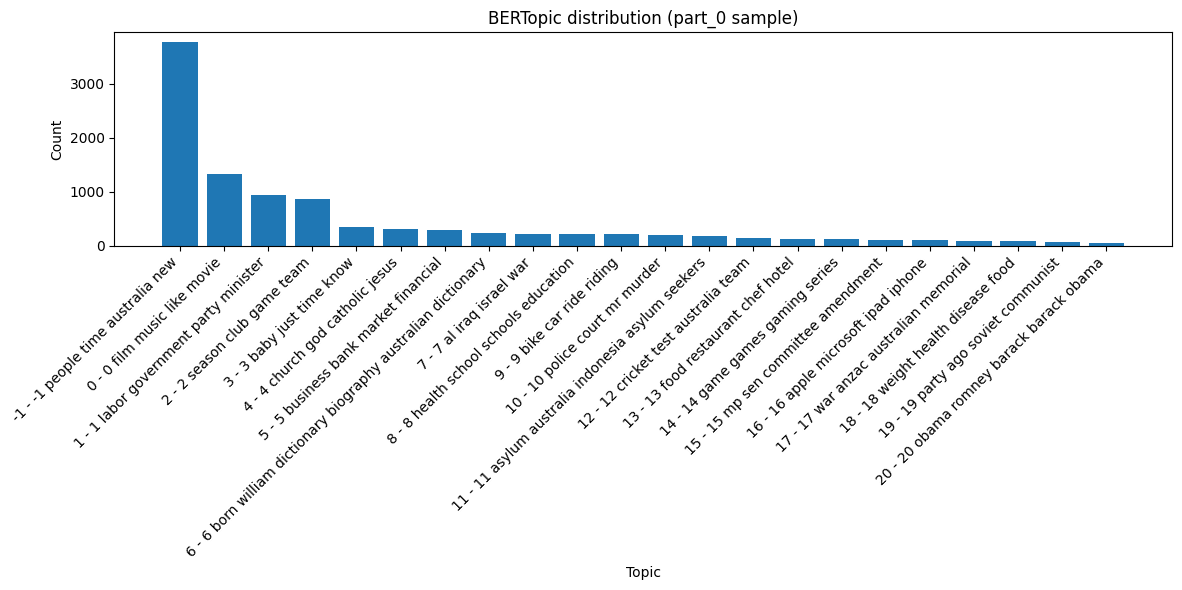

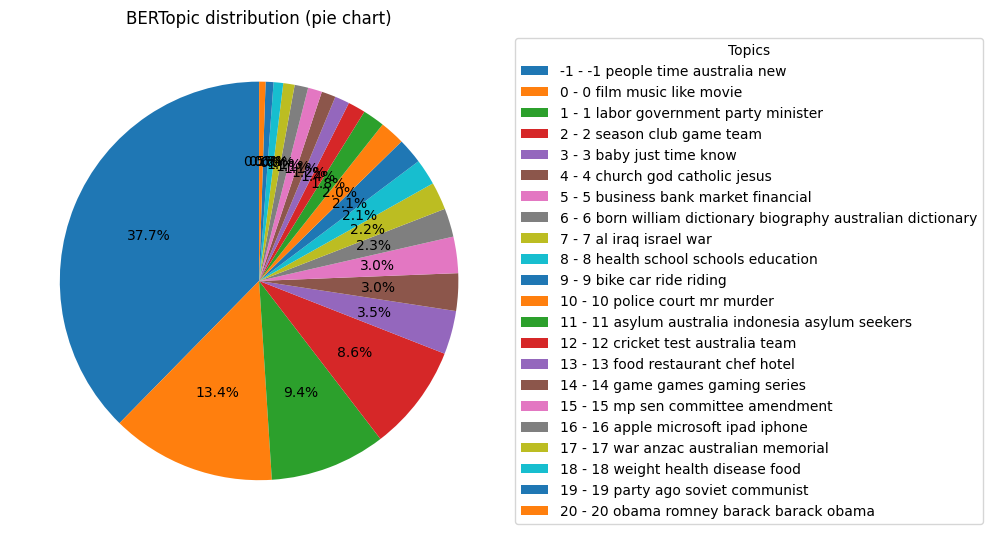

In [13]:
# =========================================================
# 12. Visualization
# =========================================================
plot_df = topic_summary.copy()

plot_df["topic_label"] = plot_df.apply(
    lambda r: f'{int(r["topic_id"])} - {r["topic_name"]}' if pd.notna(r["topic_name"]) else str(int(r["topic_id"])),
    axis=1
)

# ----- Bar chart -----
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(plot_df["topic_label"], plot_df["count"])
ax.set_title("BERTopic distribution (part_0 sample)")
ax.set_xlabel("Topic")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

topic_bar_plot_path = OUTPUT_DIR / "part_0_bertopic_distribution_bar_v02.png"
plt.savefig(topic_bar_plot_path, dpi=160, bbox_inches="tight")
plt.show()

# ----- Pie chart -----
fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    plot_df["count"],
    labels=None,
    autopct="%1.1f%%",
    startangle=90
)
ax.set_title("BERTopic distribution (pie chart)")
ax.legend(
    wedges,
    plot_df["topic_label"],
    title="Topics",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
plt.tight_layout()

topic_pie_plot_path = OUTPUT_DIR / "part_0_bertopic_distribution_pie_v02.png"
plt.savefig(topic_pie_plot_path, dpi=160, bbox_inches="tight")
plt.show()

## Cell purpose: optional interactive BERTopic visualizations

In [14]:
# =========================================================
# 13. Optional interactive BERTopic visualizations
# =========================================================
# Uncomment if needed:
# topic_model.visualize_barchart()
# topic_model.visualize_topics()
# topic_model.visualize_heatmap()

print("Interactive BERTopic visualizations are optional and currently skipped.")

Interactive BERTopic visualizations are optional and currently skipped.


## Cell purpose: save outputs

In [15]:
# =========================================================
# 14. Save outputs
# =========================================================
sample_out = OUTPUT_DIR / "part_0_bertopic_sample_with_topics_v02.parquet"
topic_summary_out = OUTPUT_DIR / "part_0_bertopic_topic_summary_v02.csv"
topic_words_out = OUTPUT_DIR / "part_0_bertopic_topic_words_v02.csv"
rep_out = OUTPUT_DIR / "part_0_bertopic_representative_docs_v02.csv"
meta_out = OUTPUT_DIR / "part_0_bertopic_run_meta_v02.json"

work_df.to_parquet(sample_out, index=False)
topic_summary.to_csv(topic_summary_out, index=False)
topic_words_df.to_csv(topic_words_out, index=False)
rep_df.to_csv(rep_out, index=False)

meta = {
    "parquet_path": str(PARQUET_PATH),
    "output_dir": str(OUTPUT_DIR),
    "sample_size": int(len(work_df)),
    "text_col": TEXT_COL,
    "url_col": URL_COL,
    "embedding_model": EMBED_MODEL_NAME,
    "device": DEVICE,
    "use_cudf": bool(USE_CUDF),
    "min_topic_size": MIN_TOPIC_SIZE,
    "nr_top_words": NR_TOP_WORDS,
}
with open(meta_out, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("Saved outputs:")
for p in [sample_out, topic_summary_out, topic_words_out, rep_out, meta_out]:
    print(" -", p)

Saved outputs:
 - /home/jovyan/cleaning_outputs/week4/part_0_bertopic_sample_with_topics_v02.parquet
 - /home/jovyan/cleaning_outputs/week4/part_0_bertopic_topic_summary_v02.csv
 - /home/jovyan/cleaning_outputs/week4/part_0_bertopic_topic_words_v02.csv
 - /home/jovyan/cleaning_outputs/week4/part_0_bertopic_representative_docs_v02.csv
 - /home/jovyan/cleaning_outputs/week4/part_0_bertopic_run_meta_v02.json


Overview of Results

This version ran successfully and produced a usable first-pass result for Task 2:

It loaded part_0.parquet
It sampled 10,000 texts froTask 2: Topic Distribution Analysis
3.1 Method Design

For Task 2, the decision was made to work on a single shard, part_0.parquet, and use:

BERT-family embeddings
BERTopic

to discover topics and estimate content distribution.

Compared with the earlier KMeans-based clustering version, BERTopic was adopted because it can directly produce:

topic words
topic summaries
representative documents
topic distribution charts

which makes it more suitable for corpus profiling.

3.2 Experimental Results

On a 10,000-document sample from part_0.parquet, the BERTopic version ran successfully and produced:

topic_info
topic_summary
topic_words
representative_docs
bar chart / pie chart
parquet / csv / json output files
3.3 Main Findings

The current results show that:

the topic words are significantly better than in the earlier version
they are no longer dominated by stopword-heavy labels such as the_to_and_of
several larger topics already show recognizable directions, such as:
film / music / movie
labor / government / minister
season / club / game / team

However, there are still clear limitations:

Topic -1 is very large, at about 37.65%
this indicates that many texts were not stably assigned to a specific topic
some topic names are still too rough to use directly in a formal report
3.4 Current Conclusion

At this stage, Task 2 already provides:

a usable initial corpus profiling result

but it still requires further tuning and manual interpretation before it can support a more polished topic-distribution analysis for reporting or paper writing.m the shard
It generated embeddings using all-MiniLM-L6-v2
It applied BERTopic for topic modeling
It produced:
topic_info
topic_summary
topic_words
representative_docs
bar chart / pie chart
parquet / csv / json output files

From the topic distribution, the most notable observation is that:

Topic -1 accounts for a large share, approximately 37.65%
This indicates that a substantial portion of the texts were treated by BERTopic as outliers or were not stably assigned to a clear topic

The other larger topics roughly include:

film / music / movie
labor / government / minister
season / club / game / team
as well as several religion-, parenting-, and law/parliament-related topics

Strengths

1. The model is now producing more interpretable topic words

Compared with the previous version, which was heavily polluted by stopword-like labels such as the_to_and_of, this version shows a clear improvement.

The current topic words are much closer to real content, for example:

film music movie
labor government minister
season club game team

This suggests that the following two changes were effective:

CountVectorizer(stop_words="english")
KeyBERTInspired()

2. The output structure is complete

This version does not only produce figures, but also exports:

topic_summary.csv
topic_words.csv
representative_docs.csv

This makes it much more suitable for subsequent report writing and for further manual interpretation of the topics.

3. The general topic directions are becoming readable

At least for the larger topics, some broad content directions are already visible, such as:

entertainment / film / music
politics / government
sports
religion

This means the current version already has value as an initial content distribution analysis.

Weaknesses

1. The proportion of Topic -1 is too high

This is currently the most obvious issue.

-1 = 3765 / 10000
share = 37.65%

This suggests that:

a large number of texts were not stably grouped into a clear topic
under the current BERTopic settings, the clustering boundaries are still not ideal

This directly affects:

the readability of the pie chart
the reliability of the distribution statistics
the quality of later topic interpretation

2. Some topic names are still too rough

Although much better than before, some names still look overly machine-generated, for example:

baby just time know
people time australia new

These labels roughly indicate a content direction, but they are still not clean enough to be used directly in a paper or formal report.

3. The texts were uniformly truncated to 1500 characters

From the output:

char_len is uniformly 1500

This means that almost all texts were truncated at the upper limit.

This may introduce two issues:

some topic signals may have been cut off
the resulting topics may be biased toward the beginning of the documents rather than the full content

Possible Improvements

1. Prioritize reducing the size of Topic -1

This should be the first priority.

Possible adjustments include:

tuning MIN_TOPIC_SIZE
reducing it so that more texts can enter concrete topics
trying BERTopic topic reduction or other parameter tuning options

For example, it would be reasonable to test:

MIN_TOPIC_SIZE = 30
or 40

instead of the current 50

2. Further improve topic representation

Although the labels are no longer dominated by stopwords, there is still room to improve topic quality.

Possible directions include:

tuning CountVectorizer
keeping ngram_range=(1,2)
increasing or decreasing min_df
post-processing the topic names
finally renaming the main topics manually into cleaner labels, such as:
arts_entertainment
government_politics
sports
religion
parenting

Task 2: Topic Distribution Analysis
3.1 Method Design

For Task 2, the decision was made to work on a single shard, part_0.parquet, and use:

BERT-family embeddings
BERTopic

to discover topics and estimate content distribution.

Compared with the earlier KMeans-based clustering version, BERTopic was adopted because it can directly produce:

topic words
topic summaries
representative documents
topic distribution charts

which makes it more suitable for corpus profiling.

3.2 Experimental Results

On a 10,000-document sample from part_0.parquet, the BERTopic version ran successfully and produced:

topic_info
topic_summary
topic_words
representative_docs
bar chart / pie chart
parquet / csv / json output files
3.3 Main Findings

The current results show that:

the topic words are significantly better than in the earlier version
they are no longer dominated by stopword-heavy labels such as the_to_and_of
several larger topics already show recognizable directions, such as:
film / music / movie
labor / government / minister
season / club / game / team

However, there are still clear limitations:

Topic -1 is very large, at about 37.65%
this indicates that many texts were not stably assigned to a specific topic
some topic names are still too rough to use directly in a formal report
3.4 Current Conclusion

At this stage, Task 2 already provides:

a usable initial corpus profiling result

but it still requires further tuning and manual interpretation before it can support a more polished topic-distribution analysis for reporting or paper writing.